# Support Vector Regression (SVR) Supervised Learning

## 1. Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import RBFSampler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load and preprocess data

In [4]:
# Load dataset
df = pd.read_csv("dataset.csv")

# One-hot encode 'stock' column
df = pd.get_dummies(df, columns=['stock'])

# Remove leaking columns
df.drop(['next_weeks_open', 'percent_change_next_weeks_price'], axis=1, inplace=True)

# Replace missing values in specified columns
cols = ['previous_weeks_volume', 'percent_change_volume_over_last_wk']
df[cols] = df[cols].replace('?', 0)

# Handle date column
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df.drop('date', axis=1, inplace=True)

# Convert dollar strings to floats
for col in df.select_dtypes(include='object').columns:
    if df[col].str.contains('^\$').any():
        df[col] = df[col].str.replace('[$,]', '', regex=True).astype(float)

# Move target to the end
y = df.pop('next_weeks_close').values
X = df.values

# Split into train+val and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Further split train+val into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

# Scale features
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

# Scale target
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()

<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
/var/folders/16/22h86xpd7j33w8md_8shh5gh0000gn/T/ipykernel_91280/1831441041.py:23: SyntaxWarning: invalid escape sequence '\$'
  if df[col].str.contains('^\$').any():


## 3. Define feature transformations and hyperparameter grid

In [5]:
C_values = [0.01, 0.1, 1, 10, 100, 1000]
transformers = {
    'Polynomial (degree=2)': PolynomialFeatures(degree=2, include_bias=False),
    'PCA (95% variance)': PCA(n_components=0.95, random_state=42),
    'RBFSampler (gamma=1)': RBFSampler(gamma=1, random_state=42)
}

## 4. Run experiments

In [ ]:
results = []
for name, transformer in transformers.items():
    # Apply transformation
    X_tr = transformer.fit_transform(X_train_scaled)
    X_vl = transformer.transform(X_val_scaled)
    X_te = transformer.transform(X_test_scaled)

    # Re-scale after transformation
    scaler_t = StandardScaler()
    X_tr = scaler_t.fit_transform(X_tr)
    X_vl = scaler_t.transform(X_vl)
    X_te = scaler_t.transform(X_te)

    for C in C_values:
        # Use linear kernel after explicit feature mapping
        svr = SVR(kernel='linear', C=C)
        svr.fit(X_tr, y_train_scaled)

        # Predictions (scaled)
        y_tr_pred = svr.predict(X_tr)
        y_vl_pred = svr.predict(X_vl)

        # Inverse-transform to original scale
        y_tr_orig = y_scaler.inverse_transform(y_tr_pred.reshape(-1, 1)).ravel()
        y_vl_orig = y_scaler.inverse_transform(y_vl_pred.reshape(-1, 1)).ravel()

        # Compute metrics
        mse_tr = mean_squared_error(y_train, y_tr_orig)
        mse_vl = mean_squared_error(y_val, y_vl_orig)
        r2_tr = r2_score(y_train, y_tr_orig)
        r2_vl = r2_score(y_val, y_vl_orig)

        results.append({
            'transformation': name,
            'C': C,
            'mse_train': mse_tr,
            'mse_val': mse_vl,
            'r2_train': r2_tr,
            'r2_val': r2_vl
        })

# Convert to DataFrame and save
df_results = pd.DataFrame(results)
df_results.to_csv('svr_experiment_results.csv', index=False)
df_results.head()

,transformation,C,mse_train,mse_val,r2_train,r2_val
0,Polynomial (degree=2),0.01,5.721927,8.051109,0.994750,0.992374
1,Polynomial (degree=2),0.10,5.629736,8.919860,0.994835,0.991551
2,Polynomial (degree=2),1.00,5.629736,8.919860,0.994835,0.991551
3,Polynomial (degree=2),10.00,5.629736,8.919860,0.994835,0.991551
4,Polynomial (degree=2),100.00,5.629736,8.919860,0.994835,0.991551


In [ ]:
## 6. Test‐Set Evaluation for SVR

best_row = df_results.loc[df_results['r2_val'].idxmax()]
best_transformation = best_row['transformation']
best_C = best_row['C']
# 1) Refit best SVR on train+val
svr_final = SVR(kernel='linear', C=best_C)
svr_final.fit(X_train_scaled, y_train_scaled)

# 2) Predict on test (scaled)
y_test_pred_scaled = svr_final.predict(X_test_scaled)

# 3) Inverse‐transform to original units
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1,1)).ravel()

# 4) Compute metrics
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test  = r2_score(y_test,  y_test_pred)

print(f"Test MSE: {mse_test:.4f}")
print(f"Test  R²: { r2_test:.4f}")

Test MSE: 4.8218
Test  R²: 0.9956


## 5. Plot performance vs. Regularization

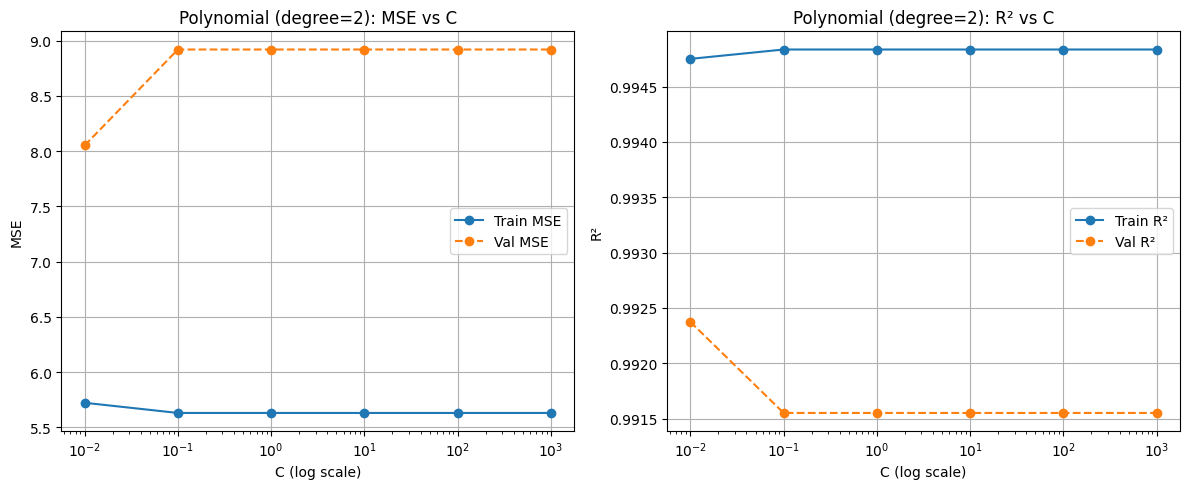

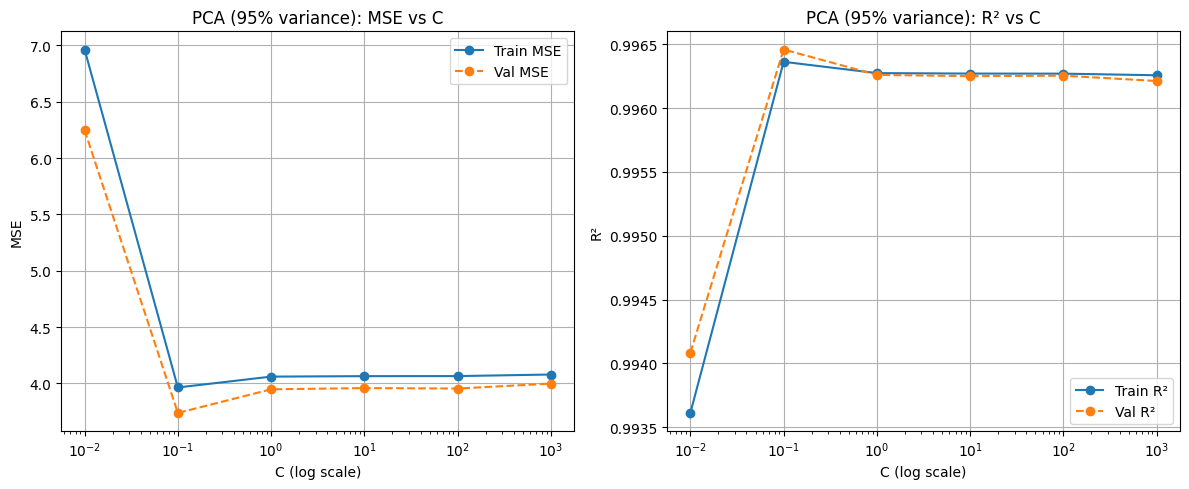

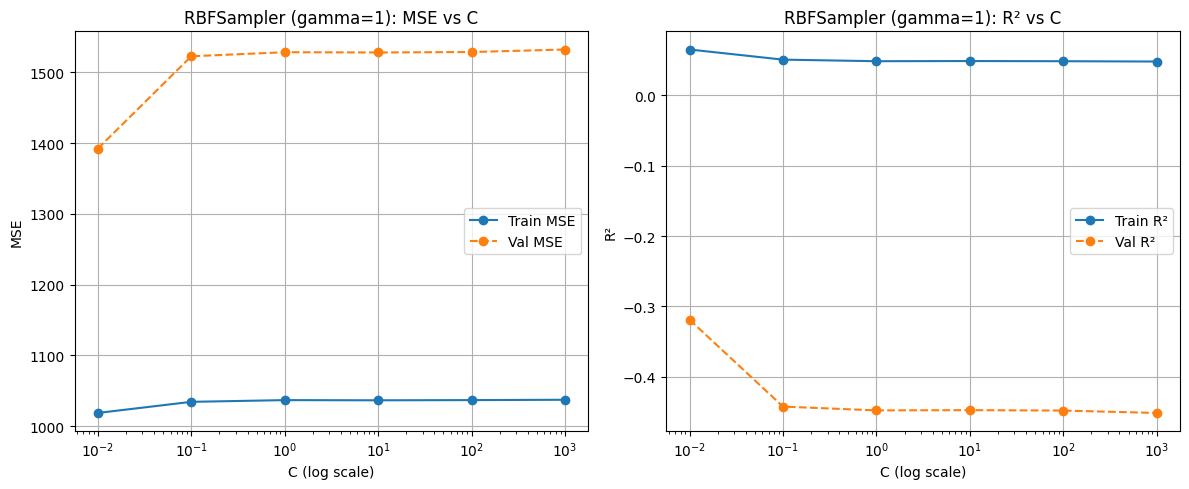

In [5]:
for name in transformers.keys():
    subset = df_results[df_results['transformation'] == name]
    subset = subset.sort_values('C')

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(subset['C'], subset['mse_train'], marker='o', label='Train MSE')
    plt.plot(subset['C'], subset['mse_val'], marker='o', linestyle='--', label='Val MSE')
    plt.xscale('log')
    plt.xlabel('C (log scale)')
    plt.ylabel('MSE')
    plt.title(f"{name}: MSE vs C")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(subset['C'], subset['r2_train'], marker='o', label='Train R²')
    plt.plot(subset['C'], subset['r2_val'], marker='o', linestyle='--', label='Val R²')
    plt.xscale('log')
    plt.xlabel('C (log scale)')
    plt.ylabel('R²')
    plt.title(f"{name}: R² vs C")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()